# Temporary: find and show very blurry PCam patches

Uses **Laplacian variance** on grayscale (0–255): low variance ≈ blurry or nearly blank. Values are in the **1–100+** range (not 0.001) because variance is computed on the raw Laplacian of 96×96 uint8 images. So we use a **percentile-based** threshold: "very blurry" = bottom 2% of blur scores in the sample.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import laplace

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)
print("Loaded train:", train_x.shape)

Loaded train: (262144, 96, 96, 3)


In [2]:
# Compute Laplacian variance (blur score) for each patch.
# Low variance = blurry (few edges). Scores depend on image scale (0-255) and size; use percentile.
n_sample = min(10000, len(train_x))
np.random.seed(42)

indices = np.random.choice(len(train_x), size=n_sample, replace=False)

blur_scores = []
for i in indices:
    patch = np.asarray(train_x[i])
    if patch.max() <= 1.0:
        patch = (np.clip(patch, 0, 1) * 255).astype(np.uint8)
    gray = np.dot(patch[..., :3], [0.299, 0.587, 0.114]).astype(np.float64)
    score = float(np.var(laplace(gray)))
    blur_scores.append((i, score))

blur_scores = np.array(blur_scores)  # shape (n_sample, 2)
idx_col = 0
score_col = 1
scores = blur_scores[:, score_col]

# Blur values are on the scale of the image (0-255) and patch size, so they're often 1–100+, not 0.001.
print("Blur score (Laplacian var) distribution:")
print(f"  min={scores.min():.2f}, 1st%={np.percentile(scores, 1):.2f}, 5th%={np.percentile(scores, 5):.2f}, 25th%={np.percentile(scores, 25):.2f}")
print(f"  median={np.median(scores):.2f}, 75th%={np.percentile(scores, 75):.2f}, 95th%={np.percentile(scores, 95):.2f}, max={scores.max():.2f}")

# Define "very blurry" as bottom 2% by score (percentile-based; no absolute threshold).
BLUR_PERCENTILE = 2
blur_threshold = np.percentile(scores, BLUR_PERCENTILE)
very_blurry = blur_scores[blur_scores[:, score_col] <= blur_threshold]
print(f"\nVery blurry = bottom {BLUR_PERCENTILE}% (score <= {blur_threshold:.2f}): {len(very_blurry)} patches")

Blur score (Laplacian var) distribution:
  min=0.29, 1st%=388.34, 5th%=2223.85, 25th%=7535.00
  median=12403.96, 75th%=17145.18, 95th%=24256.98, max=34577.40

Very blurry = bottom 2% (score <= 956.69): 200 patches


C:\Users\tamer\AppData\Local\Temp\ipykernel_13516\496819612.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = int(train_y[idx])


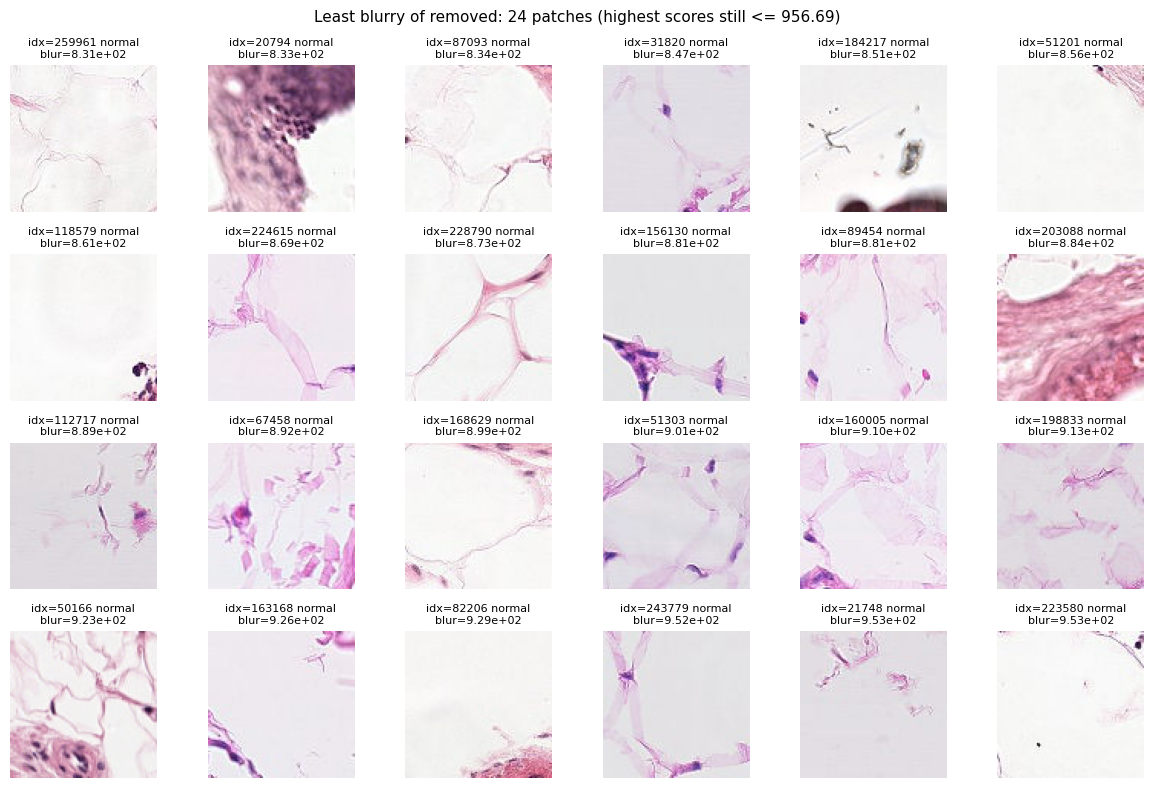

In [5]:
# Show the *least* blurry among those removed (highest scores still below threshold)
n_show = 24
sorted_removed = very_blurry[np.argsort(very_blurry[:, score_col])]  # ascending by score
to_show = sorted_removed[-n_show:]  # last 24 = highest scores in very_blurry (least blurry of removed)
show_indices = to_show[:, idx_col].astype(int)
show_scores = to_show[:, score_col]

nrows, ncols = 4, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
for k, (idx, score) in enumerate(zip(show_indices, show_scores)):
    ax = axes.flat[k]
    patch = np.asarray(train_x[idx])
    if patch.max() <= 1.0:
        patch = np.clip(patch, 0, 1)
    ax.imshow(patch)
    lab = int(train_y[idx])
    cls = "abnormal" if lab == 1 else "normal"
    ax.set_title(f"idx={idx} {cls}\nblur={score:.2e}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Least blurry of removed: {n_show} patches (highest scores still <= {blur_threshold:.2f})", fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\tamer\AppData\Local\Temp\ipykernel_13516\3876258232.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lab = int(train_y[idx])


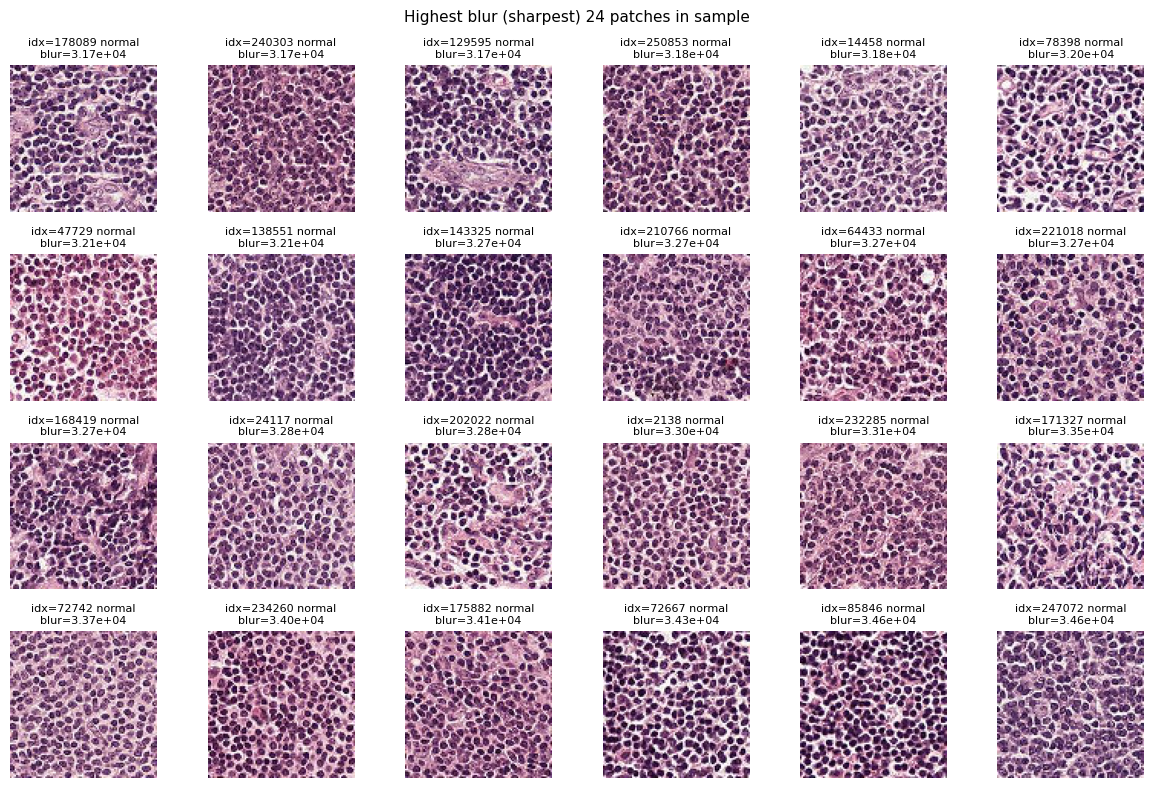

In [6]:
# Highest blur scores (least blurry / sharpest) for quality comparison
n_show_high = 24
sorted_all = blur_scores[np.argsort(blur_scores[:, score_col])]
sharpest = sorted_all[-n_show_high:]  # top 24 by score
idx_sharp = sharpest[:, idx_col].astype(int)
score_sharp = sharpest[:, score_col]

fig2, axes2 = plt.subplots(4, 6, figsize=(12, 8))
for k, (idx, score) in enumerate(zip(idx_sharp, score_sharp)):
    ax = axes2.flat[k]
    patch = np.asarray(train_x[idx])
    if patch.max() <= 1.0:
        patch = np.clip(patch, 0, 1)
    ax.imshow(patch)
    lab = int(train_y[idx])
    cls = "abnormal" if lab == 1 else "normal"
    ax.set_title(f"idx={idx} {cls}\nblur={score:.2e}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Highest blur (sharpest) {n_show_high} patches in sample", fontsize=11)
plt.tight_layout()
plt.show()